In [3]:
# 1. Import Libraries
# -------------------
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt



In [4]:
# 2. Set Random Seeds and Device
# ------------------------------
# Set Random Seeds for Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU Availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


In [5]:
# 3. Data Preprocessing
# ---------------------
# ---------------------
# Ensure that the CSV has the following columns:
# 'Type_of_aggregates', 'Curing_age_(days)', 'UPV_(m/s)', 'Er_(ohm-cm)', 'Cs_(Mpa)', and 'Design_F\'c (Mpa)'
try:
    data = pd.read_csv('/content/Untitled spreadsheet - Untitled spreadsheet - Data.csv')  # Update the path as necessary
except FileNotFoundError:
    raise FileNotFoundError("The file 'Data.csv' was not found. Please ensure the file exists in the specified path.")

# Display the first few rows to verify
print("\nFirst 5 rows of the dataset:")
print(data.head())
print(data.describe())

# Convert 'Type_of_aggregates' Categorical Feature to Numerical Codes
if 'Type_of_aggregates' in data.columns:
    data['Type_of_aggregates'] = data['Type_of_aggregates'].astype('category').cat.codes
else:
    raise ValueError("Column 'Type_of_aggregates' not found in the dataset.")

# Drop Irrelevant Column
if "Design_F'c (Mpa)" in data.columns:
    data = data.drop("Design_F'c (Mpa)", axis=1)
else:
    print("Column 'Design_F'c (Mpa)' not found in the dataset. Proceeding without dropping.")

# Check for missing values
print("\nMissing values in each column:")
print(data.isnull().sum())

# Define Numerical Features for Scaling
numerical_features = ['Curing_age_(days)', 'UPV_(m/s)', 'Er_(ohm-cm)']

# Check if all numerical features exist
for feature in numerical_features:
    if feature not in data.columns:
        raise ValueError(f"Numerical feature '{feature}' not found in the dataset.")

# Initialize Scaler
scaler = StandardScaler()

# Fit and Transform Numerical Features
data[numerical_features] = scaler.fit_transform(data[numerical_features])

# Define Input Features (X) and Target Variable (y)
if 'Cs_(Mpa)' not in data.columns:
    raise ValueError("Target column 'Cs_(Mpa)' not found in the dataset.")
X = data.drop('Cs_(Mpa)', axis=1)
y = data['Cs_(Mpa)']

# Convert All Features to Numeric Format and Handle Missing Values
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
y = pd.to_numeric(y, errors='coerce').fillna(0)

# Split Dataset into Training (70%), Validation (15%), and Test (15%) Sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42
)  # 0.1765 * 0.85 ≈ 0.15

print(f"\nDataset sizes:")
print(f"Training: {X_train.shape[0]} samples")
print(f"\nTraining_dataset",X_train.describe())
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# Convert Data to PyTorch Tensors and Move to Device
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1).to(device)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1).to(device)



First 5 rows of the dataset:
  Type_of_aggregates  Design_F'c (Mpa)  Curing_age_(days)  Cs_(Mpa)  \
0            Rounded                25                  3    5.2154   
1            Rounded                25                  3    5.1528   
2            Rounded                25                  3    5.6877   
3            Rounded                25                  3    5.1476   
4            Rounded                25                  3    5.3406   

   Er_(ohm-cm)  UPV_(m/s)  
0       5.8654  2440.2989  
1       5.9471  2417.9562  
2       5.9965  2429.9277  
3       5.8751  2435.0202  
4       5.8654  2408.7969  
       Design_F'c (Mpa)  Curing_age_(days)     Cs_(Mpa)  Er_(ohm-cm)  \
count       4420.000000        4420.000000  4420.000000  4420.000000   
mean          28.959276          40.443439    31.193113     6.760444   
std            3.509038          33.308785     9.588822     2.970590   
min           25.000000           3.000000     5.082300     1.831200   
25%           2

In [6]:
print(X_train.describe())

       Type_of_aggregates  Curing_age_(days)  Er_(ohm-cm)    UPV_(m/s)
count         3093.000000        3093.000000  3093.000000  3093.000000
mean             1.071775          -0.017770    -0.016573     0.004908
std              0.956706           0.990036     0.983710     0.998873
min              0.000000          -1.124258    -1.659536    -2.607908
25%              0.000000          -0.793978    -0.718371    -0.782961
50%              1.000000          -0.373621    -0.235584    -0.140088
75%              2.000000           0.587196     0.235958     0.978466
max              3.000000           2.388726     3.167694     1.528395


In [7]:
# 4. Define the Neural Network Model
# ----------------------------------
class ConcreteStrengthANN(nn.Module):
    def __init__(self, input_size, hidden_layer_size=128):
        super(ConcreteStrengthANN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_layer_size)
        self.fc2 = nn.Linear(hidden_layer_size, hidden_layer_size)
        self.fc3 = nn.Linear(hidden_layer_size, hidden_layer_size)
        self.dropout = nn.Dropout(0.1)
        self.fc4 = nn.Linear(hidden_layer_size, 1)
        self.activation1 = nn.ReLU()
        self.activation2 = nn.Identity()  # Identity activation for output layer

    def forward(self, x):
        x = self.activation1(self.fc1(x))
        x = self.dropout(x)
        x = self.activation1(self.fc2(x))
        x = self.dropout(x)
        x = self.activation1(self.fc3(x))
        x = self.dropout(x)
        x = self.activation2(self.fc4(x))
        return x

# Instantiate the Model and Move to Device
input_size = X_train.shape[1]
model = ConcreteStrengthANN(input_size).to(device)
print("\nNeural Network Architecture:")
print(model)



Neural Network Architecture:
ConcreteStrengthANN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=128, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc4): Linear(in_features=128, out_features=1, bias=True)
  (activation1): ReLU()
  (activation2): Identity()
)


In [8]:
# 5. Define Loss Functions
# ------------------------
# ------------------------
# Data Loss: Mean Squared Error between Predicted and Actual Cs
criterion_data = nn.MSELoss()

# Define Empirical Equation Coefficients
A = 7.2086
B = 1
C = 0.4238
D = 0.7560
F = -0.4272

# Physics-Informed Loss Function Based on the Empirical Equation
def physics_informed_loss(age_scaled, UPV_scaled, ER_scaled, predicted_Cs, scaler):
    """
    Computes the physics-informed loss based on the empirical equation:
    Cs = A * log(age + 1) + C * exp(D * (UPV / 1000)) + F * log(ER)

    Parameters:
    - age_scaled: Scaled age tensor
    - UPV_scaled: Scaled UPV tensor
    - ER_scaled: Scaled ER tensor
    - predicted_Cs: Predicted Cs tensor
    - scaler: Fitted StandardScaler object
    """
    epsilon = 1e-6  # Small value to prevent log(0)

    # Inverse scale the inputs
    age_unscaled = age_scaled * scaler.scale_[0] + scaler.mean_[0]
    UPV_unscaled = UPV_scaled * scaler.scale_[1] + scaler.mean_[1]
    ER_unscaled = ER_scaled * scaler.scale_[2] + scaler.mean_[2]

    # Compute empirical Cs using the unscaled inputs
    empirical_Cs = (
        A * torch.log(age_unscaled + B + epsilon) +
        C * torch.exp(D * (UPV_unscaled / 1000)) +
        F * torch.log(ER_unscaled + epsilon)
    )

    # Compute the Mean Squared Error between predicted and empirical Cs
    loss_phy = torch.mean((predicted_Cs - empirical_Cs) ** 2)
    return loss_phy

# Boundary Loss Function to Enforce Constraints
def boundary_loss(predicted_Cs, UPV_scaled, ER_scaled, age_scaled, scaler):
    """
    Penalizes predictions that fall outside the specified ranges:
    Cs: 0 ≤ Cs ≤ 150
    UPV: 1000 ≤ UPV ≤ 6000
    ER: 10 ≤ ER ≤ 100
    Age: 0 ≤ Age ≤ 1000

    Parameters:
    - predicted_Cs: Predicted Cs tensor
    - UPV_scaled: Scaled UPV tensor
    - ER_scaled: Scaled ER tensor
    - age_scaled: Scaled age tensor
    - scaler: Fitted StandardScaler object
    """
    # Define bounds in original scale
    Cs_lower = 0.0
    Cs_upper = 150.0
    UPV_lower = 1000.0
    UPV_upper = 6000.0
    ER_lower = 10.0
    ER_upper = 100.0
    Age_lower = 0.0
    Age_upper = 1000.0

    # Inverse scale the inputs
    age_unscaled = age_scaled * scaler.scale_[0] + scaler.mean_[0]
    UPV_unscaled = UPV_scaled * scaler.scale_[1] + scaler.mean_[1]
    ER_unscaled = ER_scaled * scaler.scale_[2] + scaler.mean_[2]

    # Compute penalties for Cs
    loss_lower_Cs = torch.mean(torch.relu(Cs_lower - predicted_Cs))
    loss_upper_Cs = torch.mean(torch.relu(predicted_Cs - Cs_upper))

    # Compute penalties for UPV
    loss_lower_UPV = torch.mean(torch.relu(UPV_lower - UPV_unscaled))
    loss_upper_UPV = torch.mean(torch.relu(UPV_unscaled - UPV_upper))

    # Compute penalties for ER
    loss_lower_ER = torch.mean(torch.relu(ER_lower - ER_unscaled))
    loss_upper_ER = torch.mean(torch.relu(ER_unscaled - ER_upper))

    # Compute penalties for Age
    loss_lower_Age = torch.mean(torch.relu(Age_lower - age_unscaled))
    loss_upper_Age = torch.mean(torch.relu(age_unscaled - Age_upper))

    # Total boundary loss
    total_bnd_loss = (
        loss_lower_Cs + loss_upper_Cs +
        loss_lower_UPV + loss_upper_UPV +
        loss_lower_ER + loss_upper_ER +
        loss_lower_Age + loss_upper_Age
    )
    return total_bnd_loss


In [9]:
# 6. Initialize Optimizer and Scheduler
# -------------------------------------
# Initialize Optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Learning Rate Scheduler: Reduces LR by factor 0.5 if validation loss doesn't improve for 10 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, verbose=True
)


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [10]:
# 7. Training Loop
# -----------------
# -----------------
# Hyperparameters
lambda_phy = 0.1          # Weight for physics-informed loss
lambda_boundary = 0.05    # Weight for boundary loss
epochs = 1000
early_stopping_patience = 50
best_val_loss = float('inf')
epochs_no_improve = 0

# Lists to Store Loss Values for Visualization
train_losses = []
val_losses = []
train_data_losses = []
train_phy_losses = []
train_bnd_losses = []
val_data_loss_list = []
val_phy_loss_list = []
val_bnd_loss_list = []

# Feature Indices for 'age', 'UPV', 'ER'
# To ensure correct indexing, get column indices directly
age_idx = X_train.columns.get_loc('Curing_age_(days)')
UPV_idx = X_train.columns.get_loc('UPV_(m/s)')
ER_idx = X_train.columns.get_loc('Er_(ohm-cm)')

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    # Forward Pass: Predict Cs
    outputs = model(X_train_tensor)

    # Extract Features for Physics-Informed and Boundary Loss
    age_scaled = X_train_tensor[:, age_idx].view(-1, 1)
    UPV_scaled = X_train_tensor[:, UPV_idx].view(-1, 1)
    ER_scaled = X_train_tensor[:, ER_idx].view(-1, 1)

    # Compute Losses
    loss_data = criterion_data(outputs, y_train_tensor)
    loss_phy = physics_informed_loss(age_scaled, UPV_scaled, ER_scaled, outputs, scaler)
    loss_bnd = boundary_loss(outputs, UPV_scaled, ER_scaled, age_scaled, scaler)

    # Total Loss
    total_loss = loss_data + lambda_phy * loss_phy + lambda_boundary * loss_bnd

    # Backward Pass and Optimization
    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
    optimizer.step()

    # Validation Step
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss_data = criterion_data(val_outputs, y_val_tensor)

        # Extract Features for Validation Losses
        age_val_scaled = X_val_tensor[:, age_idx].view(-1, 1)
        UPV_val_scaled = X_val_tensor[:, UPV_idx].view(-1, 1)
        ER_val_scaled = X_val_tensor[:, ER_idx].view(-1, 1)

        # Compute Validation Losses
        val_loss_phy = physics_informed_loss(age_val_scaled, UPV_val_scaled, ER_val_scaled, val_outputs, scaler)
        val_loss_bnd = boundary_loss(val_outputs, UPV_val_scaled, ER_val_scaled, age_val_scaled, scaler)

        # Total Validation Loss (only data loss is used for scheduler)
        val_loss = val_loss_data

    # Step the Scheduler Based on Validation Data Loss
    scheduler.step(val_loss)

    # Store Losses for Visualization
    train_losses.append(total_loss.item())
    val_losses.append(val_loss.item())
    train_data_losses.append(loss_data.item())
    train_phy_losses.append(loss_phy.item())
    train_bnd_losses.append(loss_bnd.item())
    val_data_loss_list.append(val_loss_data.item())
    val_phy_loss_list.append(val_loss_phy.item())
    val_bnd_loss_list.append(val_loss_bnd.item())

    # Early Stopping Check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Optionally, save the best model here
        # torch.save(model.state_dict(), 'best_model.pth')  # Not saving as per user request
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= early_stopping_patience:
        print(f"\nEarly stopping at epoch {epoch}")
        break

    # Print Loss Every 100 Epochs
    if epoch % 100 == 0 or epoch == 1:
        print(f'Epoch [{epoch}/{epochs}], '
              f'Train Total Loss: {total_loss.item():.4f}, '
              f'Train Data Loss: {loss_data.item():.4f}, '
              f'Train Physics Loss: {loss_phy.item():.4f}, '
              f'Train Boundary Loss: {loss_bnd.item():.4f}, '
              f'Val Data Loss: {val_loss_data.item():.4f}, '
              f'Val Physics Loss: {val_loss_phy.item():.4f}, '
              f'Val Boundary Loss: {val_loss_bnd.item():.4f}')


Epoch [1/1000], Train Total Loss: 1166.6790, Train Data Loss: 1060.9236, Train Physics Loss: 1055.7175, Train Boundary Loss: 3.6721, Val Data Loss: 1041.9987, Val Physics Loss: 1050.4926, Val Boundary Loss: 3.6941
Epoch [100/1000], Train Total Loss: 26.4867, Train Data Loss: 24.9386, Train Physics Loss: 13.6493, Train Boundary Loss: 3.6624, Val Data Loss: 15.1437, Val Physics Loss: 5.5095, Val Boundary Loss: 3.6941
Epoch [200/1000], Train Total Loss: 13.5117, Train Data Loss: 11.5618, Train Physics Loss: 17.6676, Train Boundary Loss: 3.6624, Val Data Loss: 5.1138, Val Physics Loss: 12.6982, Val Boundary Loss: 3.6941
Epoch [300/1000], Train Total Loss: 11.1041, Train Data Loss: 9.1061, Train Physics Loss: 18.1484, Train Boundary Loss: 3.6624, Val Data Loss: 4.3857, Val Physics Loss: 15.4862, Val Boundary Loss: 3.6941

Early stopping at epoch 347


In [11]:
# 8. Evaluation
# -------------
# -----------------
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_loss_data = criterion_data(test_outputs, y_test_tensor)

    # Extract Features for Test Losses
    age_test_scaled = X_test_tensor[:, age_idx].view(-1, 1)
    UPV_test_scaled = X_test_tensor[:, UPV_idx].view(-1, 1)
    ER_test_scaled = X_test_tensor[:, ER_idx].view(-1, 1)

    # Compute Test Losses
    test_loss_phy = physics_informed_loss(age_test_scaled, UPV_test_scaled, ER_test_scaled, test_outputs, scaler)
    test_loss_bnd = boundary_loss(test_outputs, UPV_test_scaled, ER_test_scaled, age_test_scaled, scaler)

    # Compute R² Score
    y_test_np = y_test_tensor.cpu().numpy()
    test_pred_np = test_outputs.cpu().numpy()
    r2 = r2_score(y_test_np, test_pred_np)

    print(f"\nTest Data Loss (MSE): {test_loss_data.item():.4f}")
    print(f"Test Physics Loss (MSE): {test_loss_phy.item():.4f}")
    print(f"Test Boundary Loss (MSE): {test_loss_bnd.item():.4f}")
    print(f"Test R² Score: {r2:.4f}")



Test Data Loss (MSE): 3.7667
Test Physics Loss (MSE): 15.1078
Test Boundary Loss (MSE): 3.4700
Test R² Score: 0.9614


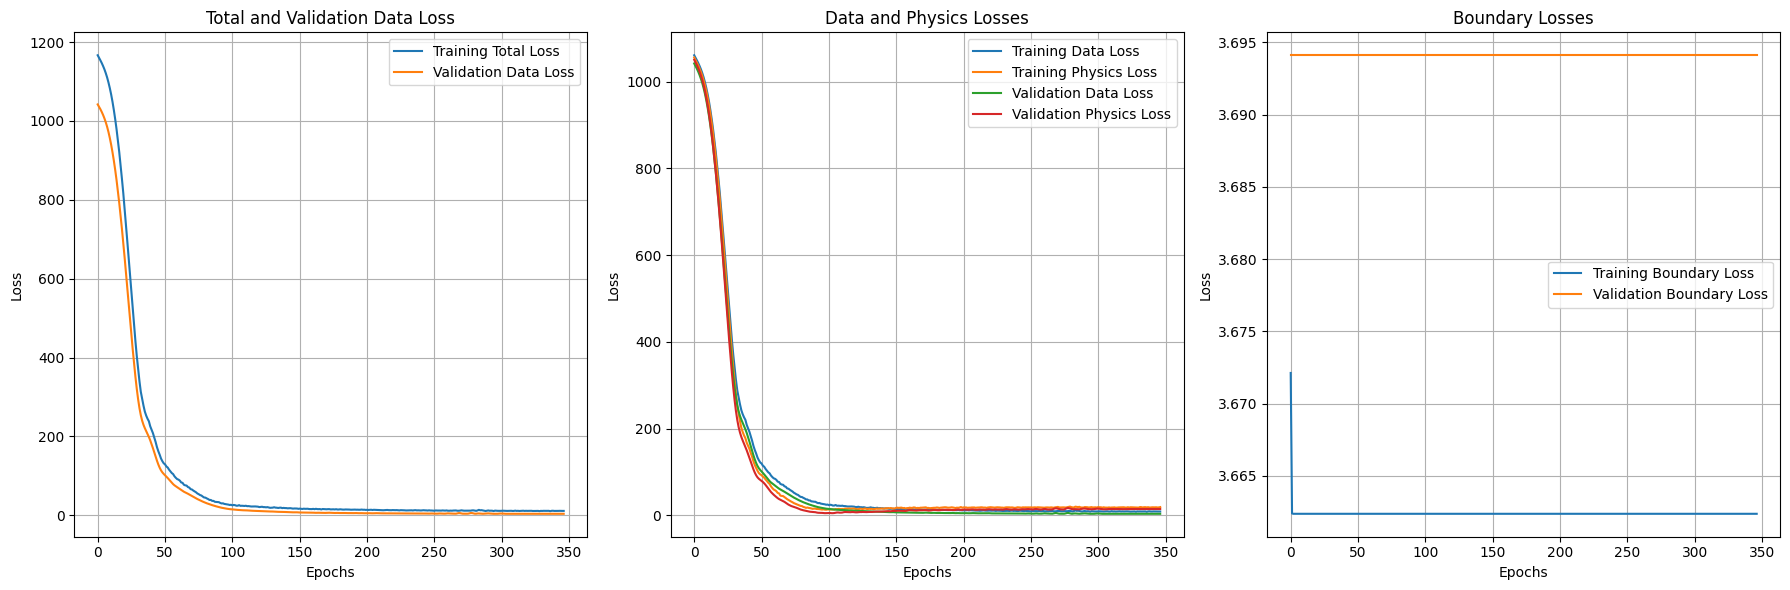

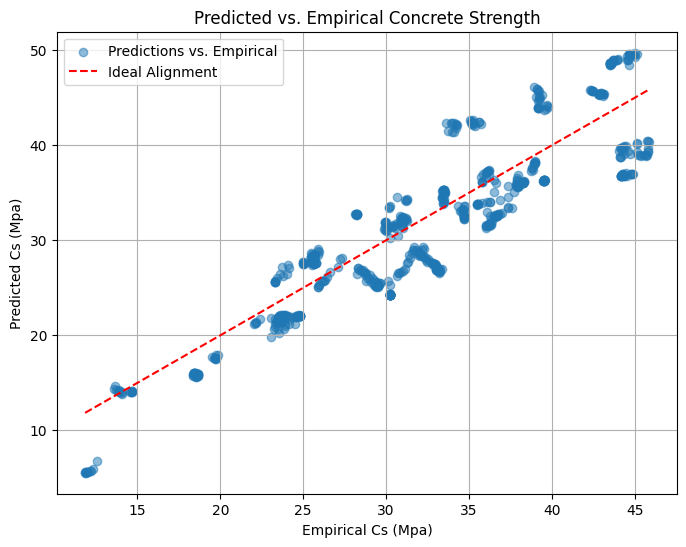

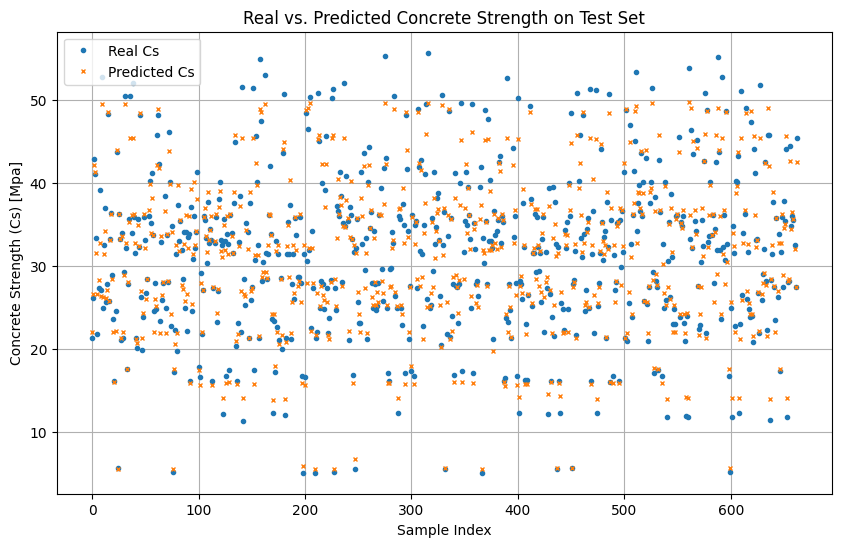

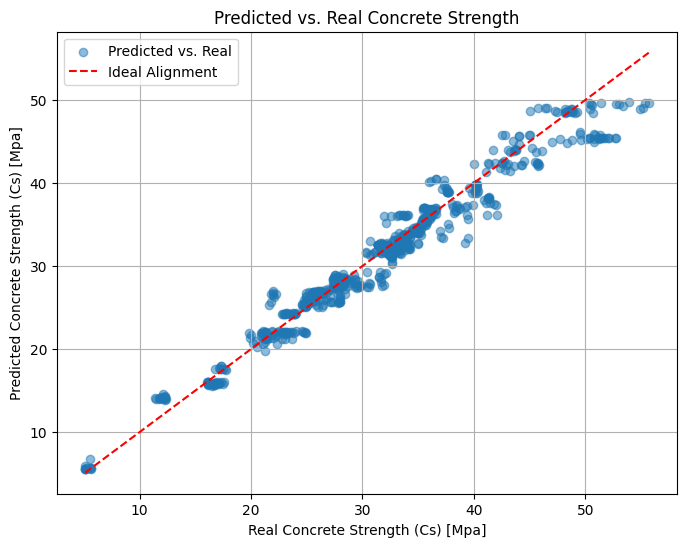

In [12]:
# 9. Visualization
# ----------------
# ----------------
# Plot Training and Validation Losses
plt.figure(figsize=(18, 6))

# Plot Total Loss and Validation Data Loss
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Training Total Loss')
plt.plot(val_losses, label='Validation Data Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Total and Validation Data Loss')
plt.legend()
plt.grid(True)

# Plot Data Loss and Physics Loss Separately
plt.subplot(1, 3, 2)
plt.plot(train_data_losses, label='Training Data Loss')
plt.plot(train_phy_losses, label='Training Physics Loss')
plt.plot(val_data_loss_list, label='Validation Data Loss')
plt.plot(val_phy_loss_list, label='Validation Physics Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Data and Physics Losses')
plt.legend()
plt.grid(True)

# Plot Boundary Losses
plt.subplot(1, 3, 3)
plt.plot(train_bnd_losses, label='Training Boundary Loss')
plt.plot(val_bnd_loss_list, label='Validation Boundary Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Boundary Losses')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Plot Predicted vs. Empirical Cs
with torch.no_grad():
    predictions = test_outputs.cpu().numpy()
    # Reconstruct Original Features from Scaled Values for Empirical Equation
    # Assuming the empirical equation uses unscaled features
    features_unscaled = scaler.inverse_transform(
        X_test[['Curing_age_(days)', 'UPV_(m/s)', 'Er_(ohm-cm)']].values
    )
    age_unscaled = features_unscaled[:, 0]
    UPV_unscaled = features_unscaled[:, 1]
    ER_unscaled = features_unscaled[:, 2]

    # Compute Empirical Cs
    empirical_Cs = (
        A * np.log(age_unscaled + B) +
        C * np.exp(D * (UPV_unscaled / 1000)) +
        F * np.log(ER_unscaled + 1e-6)  # Adding epsilon to prevent log(0)
    )

    # Plot Predicted vs. Empirical Cs
    plt.figure(figsize=(8, 6))
    plt.scatter(empirical_Cs, predictions, alpha=0.5, label='Predictions vs. Empirical')
    plt.plot([empirical_Cs.min(), empirical_Cs.max()],
             [empirical_Cs.min(), empirical_Cs.max()], 'r--', label='Ideal Alignment')
    plt.xlabel('Empirical Cs (Mpa)')
    plt.ylabel('Predicted Cs (Mpa)')
    plt.title('Predicted vs. Empirical Concrete Strength')
    plt.legend()
    plt.grid(True)
    plt.show()

# Additional Visualization: Real vs Predicted Cs on Test Set
plt.figure(figsize=(10, 6))
plt.plot(y_test_np, label='Real Cs', marker='o', linestyle='None', markersize=3)
plt.plot(test_pred_np, label='Predicted Cs', marker='x', linestyle='None', markersize=3)
plt.xlabel('Sample Index')
plt.ylabel('Concrete Strength (Cs) [Mpa]')
plt.title('Real vs. Predicted Concrete Strength on Test Set')
plt.legend()
plt.grid(True)
plt.show()

# test_pred_np: Predicted Concrete Strength values from the model

plt.figure(figsize=(8, 6))
plt.scatter(y_test_np, test_pred_np, alpha=0.5, label='Predicted vs. Real')
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'r--', label='Ideal Alignment')
plt.xlabel('Real Concrete Strength (Cs) [Mpa]')
plt.ylabel('Predicted Concrete Strength (Cs) [Mpa]')
plt.title('Predicted vs. Real Concrete Strength')
plt.legend()
plt.grid(True)
plt.show()


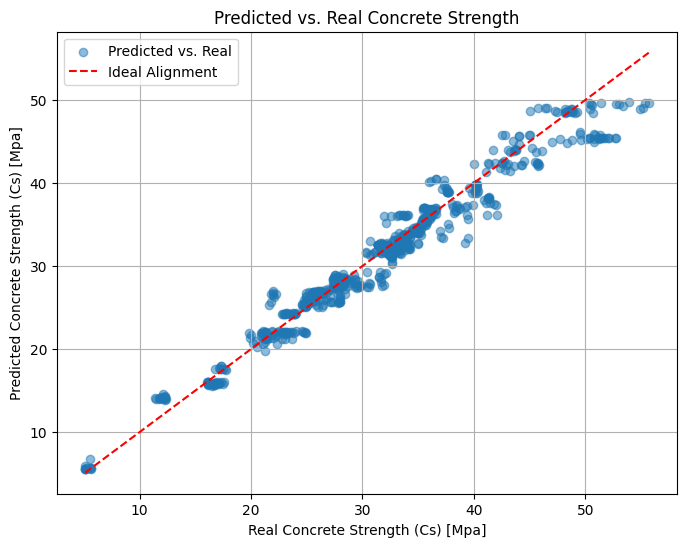

In [13]:
plt.figure(figsize=(8, 6))
# Scatter plot with Real on x-axis and Predicted on y-axis
plt.scatter(y_test_np, test_pred_np, alpha=0.5, label='Predicted vs. Real')
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'r--', label='Ideal Alignment')
# Update x-axis label
plt.xlabel('Real Concrete Strength (Cs) [Mpa]')
# Update y-axis label
plt.ylabel('Predicted Concrete Strength (Cs) [Mpa]')
plt.title('Predicted vs. Real Concrete Strength')
plt.legend()
plt.grid(True)
plt.show()

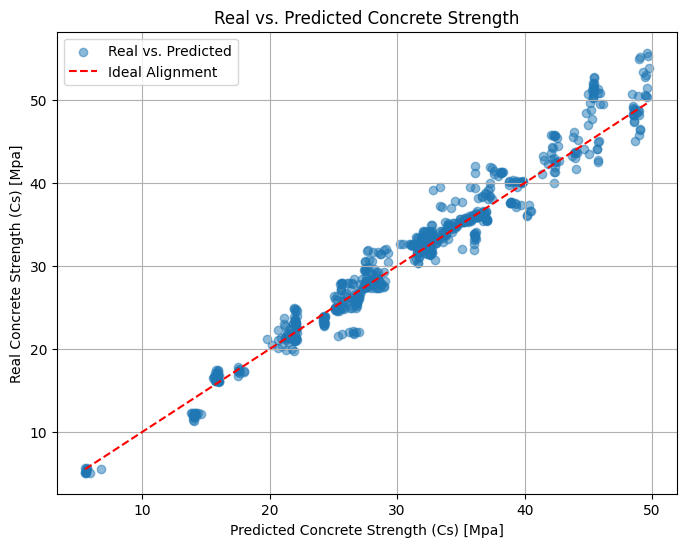

In [14]:
plt.figure(figsize=(8, 6))
# Scatter plot with Predicted on x-axis and Real on y-axis
plt.scatter(test_pred_np, y_test_np, alpha=0.5, label='Real vs. Predicted') # Swap variables here
plt.plot([test_pred_np.min(), test_pred_np.max()], [test_pred_np.min(), test_pred_np.max()], 'r--', label='Ideal Alignment')
# Update x-axis label
plt.xlabel('Predicted Concrete Strength (Cs) [Mpa]') # Update x-axis label
# Update y-axis label
plt.ylabel('Real Concrete Strength (Cs) [Mpa]') # Update y-axis label
plt.title('Real vs. Predicted Concrete Strength') # Update title (optional)
plt.legend()
plt.grid(True)
plt.show()

In [20]:
print(data)

      Type_of_aggregates  Curing_age_(days)  Cs_(Mpa)  Er_(ohm-cm)  UPV_(m/s)
0                      2          -1.124258    5.2154    -0.301336  -2.439777
1                      2          -1.124258    5.1528    -0.273830  -2.479605
2                      2          -1.124258    5.6877    -0.257198  -2.458265
3                      2          -1.124258    5.1476    -0.298070  -2.449187
4                      2          -1.124258    5.3406    -0.301336  -2.495933
...                  ...                ...       ...          ...        ...
4415                   1           1.487961   40.1515     2.483544   1.293910
4416                   1           1.487961   40.1515     2.483544   1.289758
4417                   1           1.487961   40.1515     2.483544   1.251541
4418                   1           1.487961   40.1515     2.483544   1.299484
4419                   1           1.487961   40.1515     2.483544   1.233734

[4420 rows x 5 columns]


In [17]:
# Mount Google Drive to Colab
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [18]:
# Define the path in Google Drive to save the model, including the filename
model_path = '/content/drive/MyDrive/Project/concrete_strength_model.pth'  # Added filename

# Save the trained model to Google Drive
torch.save(model.state_dict(), model_path)

print(f"Model saved successfully to {model_path}")

Model saved successfully to /content/drive/MyDrive/Project/concrete_strength_model.pth


In [19]:
# Reload the model architecture
loaded_model = ConcreteStrengthANN(input_size).to(device)

# Load the saved weights into the model
loaded_model.load_state_dict(torch.load(model_path, map_location=device))

# Set the model to evaluation mode
loaded_model.eval()
print("Model loaded successfully and ready for predictions.")


Model loaded successfully and ready for predictions.


<ipython-input-19-dc4b29280aa1>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(model_path, map_location=device))
